In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
compute_wc_vs_beta_top_simulate.py

计算 Herd Immunity Threshold (HIT) w_c 随 感染率 beta 的变化（外部干预策略：按 Phi 排序删除 top w_frac edges）。

输出：
 - out_wc/wc_vs_beta_perrun.csv  每次重复的 w_c（每行一条记录）
 - out_wc/wc_vs_beta_summary.csv 按 beta 汇总：mean_wc, std_wc, n_valid
"""

import os
import time
import math
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# -------------------- 超图生成器（与你以前实现同样逻辑） --------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------- 简化的 MMCA 类（只包含我们需要的方法） --------------------
class MMCAForHIT:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        # node incidence
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def mmca_step_given_active(self, p, Theta, active_mask, beta_d, mu, eta, gamma):
        """
        在给定 active 边掩码下做一步 MMCA 更新（向量化的思路）。
        返回 p_next, Theta_next, Phi (edge-wise p_i*p_j*p_k)。
        对于 inactive 边，我们保证 Theta_next[inactive] = 0
        """
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        Q = np.ones(self.n, dtype=float)
        for node in range(self.n):
            pv = 1.0
            for (ei,pos) in self.node_edge_pos[node]:
                if not active_mask[ei]:
                    continue
                if pos == 0:
                    oth = prod_pos0[ei]
                elif pos == 1:
                    oth = prod_pos1[ei]
                else:
                    oth = prod_pos2[ei]
                pv *= (1.0 - Theta[ei] * beta_d * oth)
            Q[node] = pv
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p

        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_next = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        Theta_next = np.clip(Theta_next, 0.0, 1.0)
        # inactive edges keep Theta=0
        Theta_next[~active_mask] = 0.0
        return p_next, Theta_next, Phi

    def run_to_steady(self, beta_d, mu, eta, gamma, init_frac, tol=1e-8, max_iter=2000, active_mask=None, Theta_init=None, p_init=None):
        """
        从给定 (p_init, Theta_init, active_mask) 起迭代到收敛，返回 steady p, Theta, Phi, iterations, rho_history（可选）
        如果 p_init/Theta_init/active_mask 为空，将做默认初始化（全1 Theta, 全 p=init_frac, active 全 True）
        """
        if active_mask is None:
            active_mask = np.ones(self.m, dtype=bool)
        if Theta_init is None:
            Theta = np.ones(self.m, dtype=float)
        else:
            Theta = Theta_init.copy()
        if p_init is None:
            p = np.full(self.n, init_frac, dtype=float)
        else:
            p = p_init.copy()

        rho_hist = []
        for it in range(max_iter):
            rho_hist.append(p.mean())
            p_next, Theta_next, Phi = self.mmca_step_given_active(p, Theta, active_mask, beta_d, mu, eta, gamma)
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta))
            p = p_next
            Theta = Theta_next
            if dp < tol and dTheta < tol:
                break
        return p, Theta, Phi, it+1, np.array(rho_hist)

# -------------------- 单次试验：对一张图在一组 w_grid 中寻找最小 w 使 rho_final < eps --------------------
def find_wc_on_graph(hyperedges, n, beta, mu, eta, gamma, init_frac, w_grid, eps, tol, max_iter, seed):
    """
    输入一张超图（通过 hyperedges），以及 beta 等参数。
    返回该图下的临界 w_c（在 w_grid 中的最小 w 使 rho_final < eps），若无则返回 np.nan。
    """
    # 初始化 model
    model = MMCAForHIT(hyperedges, n)
    # 先跑到 pre 稳态（无免疫干预）
    p_pre, Theta_pre, Phi_pre, it_pre, rho_hist_pre = model.run_to_steady(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma,
        init_frac=init_frac, tol=tol, max_iter=max_iter,
        active_mask=np.ones(model.m, dtype=bool),
        Theta_init=None, p_init=None
    )
    # 计算每条边的 Phi_e（基于 pre 稳态 p）
    Phi_e = p_pre[model.edge_i] * p_pre[model.edge_j] * p_pre[model.edge_k]
    # edges sorted descending by Phi (highest risk first)
    sorted_idx = np.argsort(-Phi_e)

    m = model.m
    # iterate w_grid from smallest to largest, find first w causing extinction
    for w in w_grid:
        if w <= 0.0:
            # 0 -> no deletion, post-state == pre-state
            rho_final = float(p_pre.mean())
            if rho_final < eps:
                return 0.0
            else:
                continue
        # how many edges to delete
        num_del = int(math.ceil(w * m))
        if num_del <= 0:
            rho_final = float(p_pre.mean())
            if rho_final < eps:
                return 0.0
            else:
                continue
        if num_del >= m:
            # delete all but one to avoid empty network (we could allow all deleted -> rho=0)
            num_del = max(0, m-1)

        del_idx = sorted_idx[:num_del]
        # build active mask (deleted -> inactive)
        active_mask = np.ones(m, dtype=bool)
        active_mask[del_idx] = False
        # Theta_pre for deleted edges set to 0 (and kept 0 moving forward)
        Theta_start = Theta_pre.copy()
        Theta_start[~active_mask] = 0.0

        # run post-phase from p_pre, Theta_start, active_mask
        p_post, Theta_post, Phi_post, it_post, rho_hist_post = model.run_to_steady(
            beta_d=beta, mu=mu, eta=eta, gamma=gamma,
            init_frac=init_frac, tol=tol, max_iter=max_iter,
            active_mask=active_mask,
            Theta_init=Theta_start,
            p_init=p_pre
        )
        rho_final = float(p_post.mean())
        if rho_final < eps:
            # found extinction at this w
            return float(w)
    # if no w in grid caused extinction
    return float('nan')

# -------------------- 并行包装器（便于 joblib 并行） --------------------
def worker_one_beta_rep(beta, rep_id, N, kappa, mu, eta, gamma, init_frac, w_grid, eps, tol, max_iter, seed_base):
    """
    对某个 beta 的单次重复（生成一张图并找 w_c），返回字典记录
    """
    gen_seed = None if seed_base is None else int(seed_base + rep_id)
    hyperedges = generate_hypergraph_H_n_m_3(N, kappa, seed=gen_seed)
    wc = find_wc_on_graph(
        hyperedges, N, beta, mu, eta, gamma, init_frac,
        w_grid=w_grid, eps=eps, tol=tol, max_iter=max_iter, seed=gen_seed
    )
    return {'beta': float(beta), 'rep': int(rep_id), 'w_c': wc}

# -------------------- 主流程（可修改参数区在脚本底部） --------------------
def compute_wc_vs_beta_top(N, kappa, beta_list, mu, eta, gamma,
                           init_frac, w_grid, eps, tol, max_iter,
                           R, seed_base, out_dir, n_jobs=1):
    os.makedirs(out_dir, exist_ok=True)
    # 并行执行：每个 (beta, rep) 一次任务
    tasks = []
    for beta in beta_list:
        for r in range(R):
            tasks.append((beta, r))
    print(f"[INFO] total tasks = {len(tasks)}  (beta points {len(beta_list)}, R={R})")

    start = time.time()
    results = Parallel(n_jobs=n_jobs, verbose=2)(
        delayed(worker_one_beta_rep)(beta, r, N, kappa, mu, eta, gamma, init_frac, w_grid, eps, tol, max_iter, seed_base)
        for (beta, r) in tasks
    )
    duration = time.time() - start
    print(f"[INFO] all tasks finished in {duration:.1f}s")

    df_runs = pd.DataFrame(results)
    runs_fn = os.path.join(out_dir, "wc_vs_beta_perrun.csv")
    df_runs.to_csv(runs_fn, index=False, float_format="%.6f")
    print(f"[INFO] saved per-run results -> {runs_fn}")

    # summary: per-beta mean & std (ignore NaN when computing mean)
    summary = df_runs.groupby('beta')['w_c'].agg(['mean', 'std', 'count']).reset_index()
    summary = summary.rename(columns={'mean': 'mean_wc', 'std': 'std_wc', 'count': 'n'})
    summary_fn = os.path.join(out_dir, "wc_vs_beta_summary.csv")
    summary.to_csv(summary_fn, index=False, float_format="%.6f")
    print(f"[INFO] saved summary -> {summary_fn}")

    return df_runs, summary

# -------------------- 参数（按需修改） --------------------
if __name__ == "__main__":
    # network / model
    N = 1500
    kappa = 6.0

    # sweep beta
    BETA_LIST = np.linspace(0.24, 0.40, 17)   # beta 范围 0.25 - 0.55
    MU = 0.1
    ETA = 0.8
    GAMMA = 0.02
    INIT_FRAC = 0.3

    # w 网格（用于查找最小使 rho* < eps 的 w）
    W_GRID = np.concatenate([
        np.arange(0.00, 0.50, 0.02),  # 粗
        np.arange(0.50, 0.70, 0.02),  # 中间精细
        np.arange(0.70, 1.00, 0.02)   # 大范围
    ])
    EPS = 1e-4   # 灭绝阈值：rho* < EPS 视为灭绝
    TOL = 1e-6
    MAX_ITER = 1500

    # repeats / parallel / randomness
    R = 40
    SEED_BASE = 12345
    OUT_DIR = "out_wc"
    N_JOBS = 18  # 并行任务数，根据你的CPU调整（或设为 1）

    # -------------------- 运行计算 --------------------
    print("Start compute w_c vs beta (Top strategy) ...")
    t0 = time.time()
    df_runs, summary = compute_wc_vs_beta_top(
        N=N, kappa=kappa, beta_list=BETA_LIST, mu=MU, eta=ETA, gamma=GAMMA,
        init_frac=INIT_FRAC, w_grid=W_GRID, eps=EPS, tol=TOL, max_iter=MAX_ITER,
        R=R, seed_base=SEED_BASE, out_dir=OUT_DIR, n_jobs=N_JOBS
    )
    print("Done. Total time: {:.1f}s".format(time.time() - t0))

Start compute w_c vs beta (Top strategy) ...
[INFO] total tasks = 34  (beta points 17, R=2)


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  17 out of  34 | elapsed:   29.9s remaining:   29.9s


[INFO] all tasks finished in 62.0s
[INFO] saved per-run results -> out_wc\wc_vs_beta_perrun.csv
[INFO] saved summary -> out_wc\wc_vs_beta_summary.csv
Done. Total time: 62.0s


[Parallel(n_jobs=18)]: Done  34 out of  34 | elapsed:  1.0min finished


图片已保存: out_wc\wc_vs_beta_simple.png


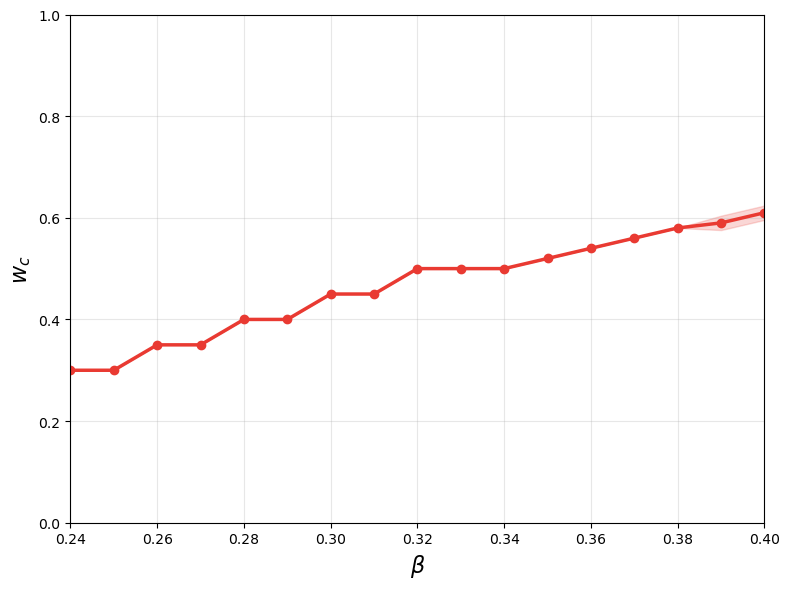

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_wc_vs_beta_simple.py

简单绘制 w_c vs beta 曲线
"""

import os
import pandas as pd
import matplotlib.pyplot as plt


"""
简单绘制 w_c vs beta 曲线
"""
# 配置
out_dir = "out_wc"
summary_file = os.path.join(out_dir, "wc_vs_beta_summary.csv")

# 加载数据
summary_df = pd.read_csv(summary_file)

# 按 beta 排序
summary_sorted = summary_df.sort_values('beta')

# 提取数据
beta = summary_sorted['beta'].to_numpy()
mean_wc = summary_sorted['mean_wc'].to_numpy()
std_wc = summary_sorted['std_wc'].to_numpy()

# 绘制图形
plt.figure(figsize=(8, 6))

# 绘制曲线和误差带
plt.plot(beta, mean_wc, '-o', label='Top', linewidth=2.5, 
            markersize=6, color='#E93A32')
plt.fill_between(beta, mean_wc - std_wc, mean_wc + std_wc, 
                alpha=0.2, color='#E93A32')

# 设置坐标轴和标签
plt.xlabel(r'$\beta$', fontsize=16)
plt.ylabel(r'$w_c$', fontsize=16)
plt.xlim(beta.min(), beta.max())
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)

# 保存图片
os.makedirs(out_dir, exist_ok=True)
output_file = os.path.join(out_dir, "wc_vs_beta_simple.png")
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"图片已保存: {output_file}")

# 显示图片
plt.show()

